![display relevant image here](path/url/to/image)
- Banner/header image

# Financial Loan Risk Prediction

## Overview
- BLUF (Bottom Line Up Front)
- One paragraph summary of final model performance and business implications
- Frame your 'story'

## Business Understanding

1. Begin by thoroughly analyzing the business context of FinTech Innovations' loan approval process. Write a short summary that:
- Describes the current manual process and its limitations
- Identifies key stakeholders and their needs
- Explains the implications of different types of model errors
- Justifies your choice between classification and regression approaches

Financial institutions traditionally rely on loan officers to manually assess loan applications by reviewing factors such as income, employment status, credit history, existing debts, and other financial information before making approval decisions. Although this process allows for professional judgment, it is often time-consuming, inconsistent, and susceptible to human error or bias, particularly when processing a large number of applications. 

The key stakeholders include:
* loan applicants - who expect fair and timely decisions 
* loan officers - who require reliable decision-support tools
* bank management - whose goal is to maximize profitability while minimizing financial losses
* the risk management team - which focuses on reducing loan defaults. 

Since the objective is to predict whether an applicant should be approved or rejected, this is a classification problem rather than a regression problem because the target variable consists of discrete categories instead of continuous values. From a business perspective, the most costly error is approving a high-risk customer who later defaults on the loan (false positive), while rejecting a creditworthy customer (false negative) mainly results in lost business opportunities. Therefore, the model should prioritize minimizing false positives to reduce financial risk.

2. Define your modeling goals and success criteria:
- Select appropriate evaluation metrics based on business impact
- You must use at least two different metrics
- Consider creating custom metric
- Establish baseline performance targets
- Document your reasoning for each choice


The primary objective of this project is to develop a machine learning classification model capable of accurately predicting whether a loan applicant is likely to be a low-risk or high-risk borrower, thereby supporting faster and more consistent loan approval decisions. Since approving a high-risk applicant has greater financial consequences than rejecting a creditworthy one, the model will prioritize minimizing false positives by optimizing precision while also considering recall and the F1-score to maintain a balance between identifying risky applicants and avoiding unnecessary loan rejections. Overall model performance will also be assessed using accuracy and the ROC-AUC score to evaluate the model’s ability to distinguish between the two classes across different decision thresholds. A baseline model will first be established before comparing multiple machine learning algorithms, with the final model selected based on its ability to achieve strong predictive performance while minimizing business risk and maintaining good generalization on unseen data.


## Data Understanding
3. Conduct comprehensive exploratory data analysis:
- Describe basic data characteristics
- Examine distributions of all features and target variables
- Investigate relationships between features
- Create visualizations to help aid in EDA
- Document potential data quality issues and their implications

4. Develop feature understanding:
- Categorize features by type (numerical, categorical, ordinal)
- Identify features requiring special preprocessing
- Document missing value patterns and their potential meanings
- Note potential feature engineering opportunities


In [238]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve
)



import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option('display.max_columns', None)

In [239]:
#load the datastet
df = pd.read_csv("Loan.csv")

#display the first five rows
df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,2,Own,183,0.354418,1,2,0.358336,0,Home,0,29,9,7632,1202,146111,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.087827,5,3,0.330274,0,Debt Consolidation,0,21,9,4627,3460,53204,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,2,Rent,902,0.137414,2,0,0.244729,0,Education,0,20,22,886,895,25176,128874,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.267587,2,1,0.436244,0,Home,0,27,10,1675,1217,104822,5370,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.320535,0,0,0.078884,0,Debt Consolidation,0,26,27,1555,4981,244305,17286,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [240]:
# Separate features and target
X = df.drop("LoanApproved", axis=1)
y = df["LoanApproved"]

In [241]:
#check shape
X.shape

(20000, 35)

After separating the target variable, the feature matrix (X) contains 20,000 observations and 35 predictor variables. This provides sufficient data for exploratory analysis and subsequent model development.

In [242]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  str    
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  str    
 5   EducationLevel              20000 non-null  str    
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  str    
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  str    
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   20000 non-null

In [243]:
# Summary statistics
X.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ApplicationDate,20000,20000,2018-01-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,20000.0,NaN,NaN,NaN,39.7526,11.622713,18.0,32.0,40.0,48.0,80.0
AnnualIncome,20000.0,NaN,NaN,NaN,59161.47355,40350.845168,15000.0,31679.0,48566.0,74391.0,485341.0
CreditScore,20000.0,NaN,NaN,NaN,571.6124,50.997358,343.0,540.0,578.0,609.0,712.0
EmploymentStatus,20000,3,Employed,17036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EducationLevel,20000,5,Bachelor,6054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Experience,20000.0,NaN,NaN,NaN,17.52275,11.316836,0.0,9.0,17.0,25.0,61.0
LoanAmount,20000.0,NaN,NaN,NaN,24882.8678,13427.421217,3674.0,15575.0,21914.5,30835.0,184732.0
LoanDuration,20000.0,NaN,NaN,NaN,54.057,24.664857,12.0,36.0,48.0,72.0,120.0
MaritalStatus,20000,4,Married,10041,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Observation: The summary statistics show that the dataset contains both numerical and categorical features. Numerical variables exhibit varying ranges and distributions, while categorical variables such as EmploymentStatus, EducationLevel, MaritalStatus, and LoanPurpose contain a limited number of unique categories. These summaries provide an initial understanding of the dataset and highlight variables that may require preprocessing or further exploration.

In [244]:
# Target distribution
y.value_counts()

LoanApproved
0    15220
1     4780
Name: count, dtype: int64

In [245]:
# Target proportions
y.value_counts(normalize=True) * 100

LoanApproved
0    76.1
1    23.9
Name: proportion, dtype: float64

Observation: Approximately 76.1% of loan applications were approved, while 23.9% were rejected. This indicates a moderate class imbalance, which should be considered during model evaluation.

In [246]:
#check for missing values
X.isna().sum().sort_values(ascending=False)

ApplicationDate               0
Age                           0
AnnualIncome                  0
CreditScore                   0
EmploymentStatus              0
EducationLevel                0
Experience                    0
LoanAmount                    0
LoanDuration                  0
MaritalStatus                 0
NumberOfDependents            0
HomeOwnershipStatus           0
MonthlyDebtPayments           0
CreditCardUtilizationRate     0
NumberOfOpenCreditLines       0
NumberOfCreditInquiries       0
DebtToIncomeRatio             0
BankruptcyHistory             0
LoanPurpose                   0
PreviousLoanDefaults          0
PaymentHistory                0
LengthOfCreditHistory         0
SavingsAccountBalance         0
CheckingAccountBalance        0
TotalAssets                   0
TotalLiabilities              0
MonthlyIncome                 0
UtilityBillsPaymentHistory    0
JobTenure                     0
NetWorth                      0
BaseInterestRate              0
Interest

Observation: No missing values were detected in the feature set. This indicates that the dataset has already been cleaned and is ready for preprocessing. Although no imputation is required for this dataset, a preprocessing pipeline will still be used to ensure a consistent and reusable machine learning workflow.

In [247]:
#check for duplicates
df.duplicated().sum()

np.int64(0)

There are no duplicate records

In [248]:
# Categorize features by data type
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object"]).columns

print("Numerical features:", len(numerical_cols))
print(numerical_cols)

print("\nCategorical features:", len(categorical_cols))
print(categorical_cols)

Numerical features: 29
Index(['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount',
       'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments',
       'CreditCardUtilizationRate', 'NumberOfOpenCreditLines',
       'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory',
       'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory',
       'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets',
       'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory',
       'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate',
       'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'RiskScore'],
      dtype='str')

Categorical features: 6
Index(['ApplicationDate', 'EmploymentStatus', 'EducationLevel',
       'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose'],
      dtype='str')


Observation:
The dataset contains *29 numerical features* and *6 categorical features*.

Most object variables represent genuine categorical data and will later be encoded within the preprocessing pipeline. However, ApplicationDate is a temporal feature rather than a categorical variable and may require feature engineering or exclusion before model training.

In [249]:
# Check the number of unique values in each categorical feature
for col in categorical_cols:
    print(f"\n{col}")
    print(X[col].value_counts())


ApplicationDate
ApplicationDate
2018-01-01    1
2018-01-02    1
2018-01-03    1
2018-01-04    1
2018-01-05    1
             ..
2072-09-29    1
2072-09-30    1
2072-10-01    1
2072-10-02    1
2072-10-03    1
Name: count, Length: 20000, dtype: int64

EmploymentStatus
EmploymentStatus
Employed         17036
Self-Employed     1573
Unemployed        1391
Name: count, dtype: int64

EducationLevel
EducationLevel
Bachelor       6054
High School    5908
Associate      4034
Master         3050
Doctorate       954
Name: count, dtype: int64

MaritalStatus
MaritalStatus
Married     10041
Single       6078
Divorced     2882
Widowed       999
Name: count, dtype: int64

HomeOwnershipStatus
HomeOwnershipStatus
Mortgage    7939
Rent        6087
Own         3938
Other       2036
Name: count, dtype: int64

LoanPurpose
LoanPurpose
Home                  5925
Debt Consolidation    5027
Auto                  4034
Education             3008
Other                 2006
Name: count, dtype: int64


Observation: Most categorical variables have low cardinality and are suitable for One-Hot Encoding during preprocessing. ApplicationDate, however, contains a unique value for every record (20,000 unique dates), making it a high-cardinality temporal feature. Instead of encoding it, the variable will be excluded from the model to avoid unnecessarily increasing the feature space.

In [250]:
# Drop ApplicationDate
X = X.drop("ApplicationDate", axis=1)

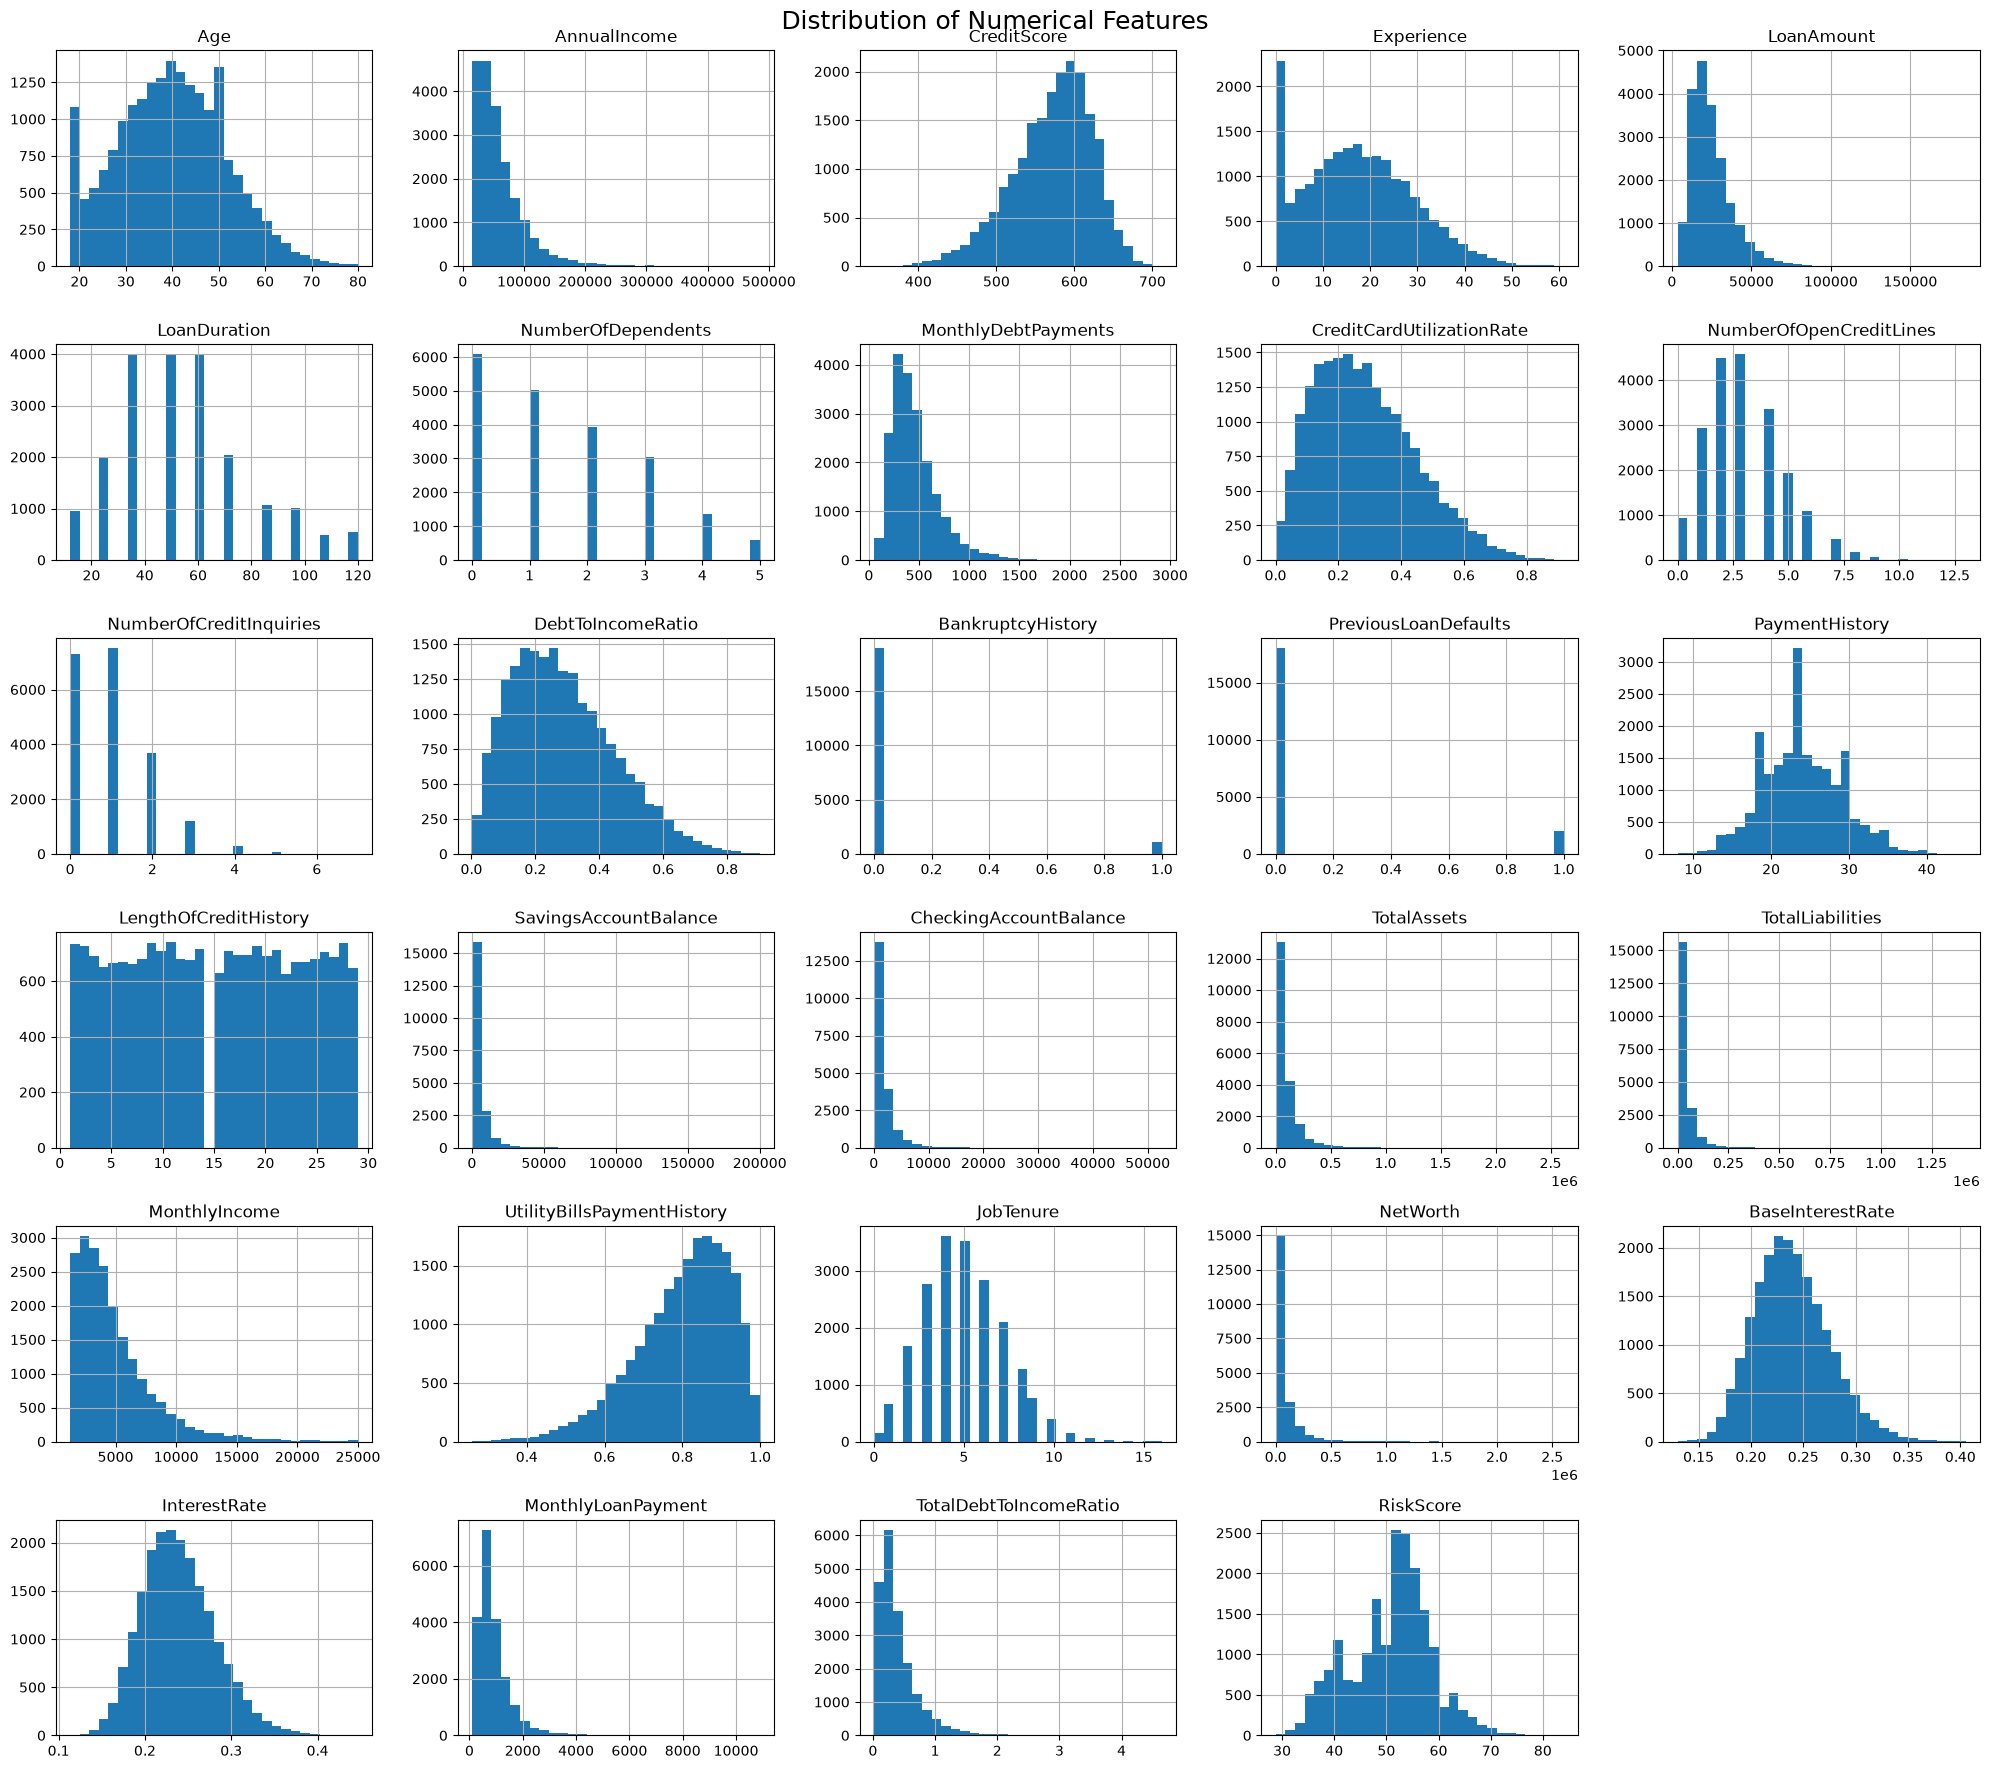

In [251]:
#Visualization
# 1. Distribution of numerical features
X[numerical_cols].hist(figsize=(20,18), bins=30)

plt.suptitle("Distribution of Numerical Features", fontsize=18)
plt.tight_layout()
plt.show()

Observation: Most numerical variables exhibit different distributions. Some variables appear approximately normally distributed, while others are positively skewed with long right tails. Features such as income, loan amount, assets, and net worth display larger ranges, suggesting that feature scaling may be beneficial during preprocessing.

## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision



In [252]:
X.columns

Index(['Age', 'AnnualIncome', 'CreditScore', 'EmploymentStatus',
       'EducationLevel', 'Experience', 'LoanAmount', 'LoanDuration',
       'MaritalStatus', 'NumberOfDependents', 'HomeOwnershipStatus',
       'MonthlyDebtPayments', 'CreditCardUtilizationRate',
       'NumberOfOpenCreditLines', 'NumberOfCreditInquiries',
       'DebtToIncomeRatio', 'BankruptcyHistory', 'LoanPurpose',
       'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory',
       'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets',
       'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory',
       'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate',
       'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'RiskScore'],
      dtype='str')

In [253]:
# drop irrelevant columns
# #drop RiskScore to avoid data leakage
X = X.drop("RiskScore", axis=1)

The RiskScore variable was removed from the feature set because it may directly reflect the applicant's risk outcome and could therefore introduce data leakage. Removing it ensures the model learns from applicant and financial characteristics rather than from a feature that may already summarize the target decision.

In [254]:
# Separate features by data type
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print(f"Numerical features: {len(numerical_cols)}")
print(f"Categorical features: {len(categorical_cols)}")

Numerical features: 28
Categorical features: 5


Observation: The features were grouped into numerical and categorical variables to enable different preprocessing steps. Numerical features will undergo median imputation and scaling, while categorical features will be imputed using the most frequent category and encoded using One-Hot Encoding.

In [255]:
# Numerical preprocessing pipeline
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


In [256]:
# Categorical preprocessing pipeline
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

Separate preprocessing pipelines were created for numerical and categorical features. Numerical features will be imputed using the median and scaled, while categorical features will be imputed using the most frequent value and encoded using One-Hot Encoding.

In [257]:
# Combine preprocessing pipelines
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

A ColumnTransformer was used to combine the numerical and categorical preprocessing pipelines. This ensures that each feature type receives the appropriate transformation before model training.

In [258]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (16000, 33)
Testing set : (4000, 33)


The dataset was split into 80% training data and 20% testing data. Stratified sampling was used to preserve the class distribution of the target variable in both sets, ensuring fair model training and evaluation.

## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune” 


#### 1. Logistic Regression Model

In [259]:
#1. Logistic Regression pipeline
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# Train the model
logreg_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['Age','AnnualIncome','CreditScore',...,'InterestRate', 'MonthlyLoanPayment','TotalDebtToIncomeRatio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyi

In [260]:
# Make predictions
y_pred_logreg = logreg_pipeline.predict(X_test)
y_proba_logreg = logreg_pipeline.predict_proba(X_test)[:, 1]

In [261]:
# Evaluate Logistic Regression metrics

accuracy = accuracy_score(y_test, y_pred_logreg)
precision = precision_score(y_test, y_pred_logreg)
recall = recall_score(y_test, y_pred_logreg)
f1 = f1_score(y_test, y_pred_logreg)
roc_auc = roc_auc_score(y_test, y_proba_logreg)

# Display evaluation metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"ROC AUC Score: {roc_auc:.2f}")

Accuracy: 0.97
Precision: 0.93
Recall: 0.93
F1 Score: 0.93
ROC AUC Score: 0.99


Logistic Regression model has achieved strong predictive performance. The model attained an accuracy of 97%, precision of 93%, recall of 93%, F1-score of 93%, and an ROC-AUC score of 0.99, indicating excellent ability to distinguish between approved and rejected loan applications while maintaining a good balance between precision and recall

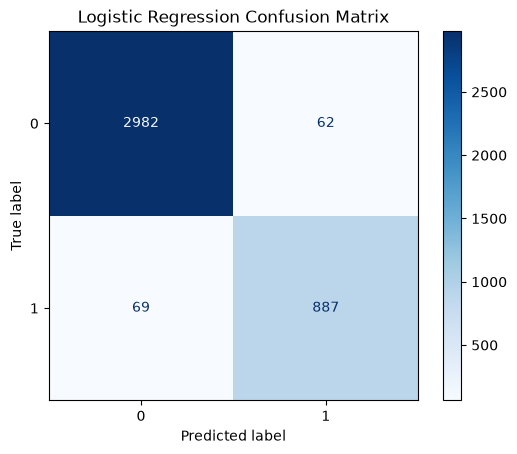

In [262]:
# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logreg,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [263]:
#classification report
print(classification_report(y_test, y_pred_logreg))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3044
           1       0.93      0.93      0.93       956

    accuracy                           0.97      4000
   macro avg       0.96      0.95      0.95      4000
weighted avg       0.97      0.97      0.97      4000



Observation: The Logistic Regression model performed well on the test data. The confusion matrix shows that most loan applications were classified correctly, with 62 false positives and 69 false negatives. The classification report further indicates high precision, recall, and F1-scores for both classes, suggesting that the model generalizes well and can accurately distinguish between approved and rejected loan applications.

In [264]:
#cross validation
cv_scores = cross_val_score(
    logreg_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:", cv_scores)
print(f"Mean CV Accuracy: {cv_scores.mean():.3f}")
print(f"Standard Deviation: {cv_scores.std():.3f}")

Cross-validation scores: [0.9621875 0.96125   0.9665625 0.96375   0.97     ]
Mean CV Accuracy: 0.965
Standard Deviation: 0.003


Observation: Five-fold cross-validation was used to evaluate the stability of the Logistic Regression model. The model achieved a mean cross-validation accuracy of *96.5%* with a very low standard deviation of *0.003*, indicating consistent performance across different subsets of the training data. This suggests that the model generalizes well and is unlikely to be overfitting.

#### 2. Decison Tree Model

In [265]:
#2. Decision Tree model
dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

# Train the model
dt_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['Age','AnnualIncome','CreditScore',...,'InterestRate', 'MonthlyLoanPayment','TotalDebtToIncomeRatio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyi

In [266]:
# Make predictions
y_pred_dt = dt_pipeline.predict(X_test)
y_proba_dt = dt_pipeline.predict_proba(X_test)[:, 1]

In [267]:
# Evaluate Decision Tree metrics
accuracy = accuracy_score(y_test, y_pred_dt)
precision = precision_score(y_test, y_pred_dt)
recall = recall_score(y_test, y_pred_dt)
f1 = f1_score(y_test, y_pred_dt)
roc_auc = roc_auc_score(y_test, y_proba_dt)

# Display evaluation metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"ROC AUC Score: {roc_auc:.2f}")

Accuracy: 0.88
Precision: 0.75
Recall: 0.77
F1 Score: 0.76
ROC AUC Score: 0.84


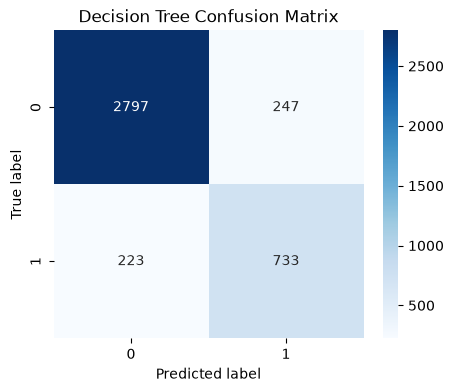

In [268]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["0", "1"],
    yticklabels=["0", "1"]
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [269]:
# Classification Report
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.93      0.92      0.92      3044
           1       0.75      0.77      0.76       956

    accuracy                           0.88      4000
   macro avg       0.84      0.84      0.84      4000
weighted avg       0.88      0.88      0.88      4000



The Decision Tree model performed reasonably well, achieving an overall accuracy of 88%. It classified the majority of both approved and rejected loan applications correctly, although it produced more false positives and false negatives than the Logistic Regression model.

In [270]:
# Cross-validation
cv_scores_dt = cross_val_score(
    dt_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:", cv_scores_dt)
print(f"Mean CV Accuracy: {cv_scores_dt.mean():.3f}")
print(f"Standard Deviation: {cv_scores_dt.std():.3f}")

Cross-validation scores: [0.88625   0.8859375 0.8953125 0.8759375 0.8934375]
Mean CV Accuracy: 0.887
Standard Deviation: 0.007


The Decision Tree achieved a mean cross-validation accuracy of 88.7% with a very low standard deviation (0.007). This indicates that the model performs consistently across different folds of the training data, suggesting stable generalization despite having lower overall accuracy than the Logistic Regression model.

#### 3. Random Forest Model

In [271]:
# 3. Random Forest model pipeline
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

# Train the model
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['Age','AnnualIncome','CreditScore',...,'InterestRate', 'MonthlyLoanPayment','TotalDebtToIncomeRatio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyi

In [272]:
# Make predictions
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

In [273]:
# Evaluate Random Forest metrics
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)
roc_auc = roc_auc_score(y_test, y_proba_rf)

# Display evaluation metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"ROC AUC Score: {roc_auc:.2f}")


Accuracy: 0.93
Precision: 0.90
Recall: 0.80
F1 Score: 0.85
ROC AUC Score: 0.98


The Random Forest model achieved an accuracy of 93% with a precision of 90%, indicating that most approved loan predictions were correct. However, the recall of 80% shows that some approved loans were still missed. The model achieved an F1-score of 85%, reflecting a good balance between precision and recall, while the high ROC-AUC score of 0.98 demonstrates excellent ability to distinguish between approved and rejected loan applications.

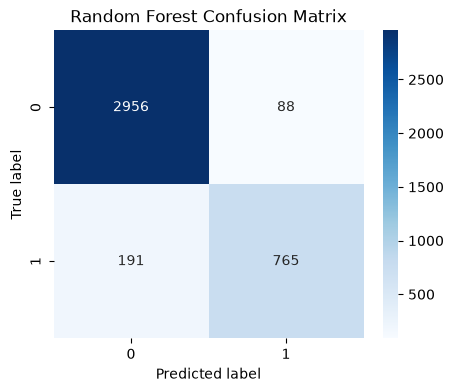

In [274]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["0", "1"],
    yticklabels=["0", "1"]
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [275]:
# Classification Report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.94      0.97      0.95      3044
           1       0.90      0.80      0.85       956

    accuracy                           0.93      4000
   macro avg       0.92      0.89      0.90      4000
weighted avg       0.93      0.93      0.93      4000



The Random Forest model correctly classified most loan applications, achieving high precision and recall for both classes. The confusion matrix shows relatively few false positives (88) and false negatives (191), while the classification report indicates an overall accuracy of 93%. Compared to the Decision Tree model, Random Forest made fewer classification errors, demonstrating better predictive performance and a stronger balance between precision and recall.

In [276]:
# Cross-validation
cv_scores_rf = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:", cv_scores_rf)
print(f"Mean CV Accuracy: {cv_scores_rf.mean():.3f}")
print(f"Standard Deviation: {cv_scores_rf.std():.3f}")

Cross-validation scores: [0.92625   0.9246875 0.9246875 0.9215625 0.930625 ]
Mean CV Accuracy: 0.926
Standard Deviation: 0.003


The Random Forest model achieved a mean cross-validation accuracy of 92.6% with a low standard deviation of 0.003. The consistent scores across the five folds indicate that the model generalizes well to unseen data and produces stable predictions with minimal performance variation.

In [277]:
# Compare baseline model performances

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [0.97, 0.88, 0.93],
    "Precision": [0.93, 0.75, 0.90],
    "Recall": [0.93, 0.77, 0.80],
    "F1 Score": [0.93, 0.76, 0.85],
    "ROC AUC": [0.99, 0.84, 0.98],
    "Mean CV Accuracy": [0.965, 0.887, 0.926]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Mean CV Accuracy
0,Logistic Regression,0.97,0.93,0.93,0.93,0.99,0.965
1,Decision Tree,0.88,0.75,0.77,0.76,0.84,0.887
2,Random Forest,0.93,0.90,0.80,0.85,0.98,0.926


Logistic Regression achieved the highest overall performance across all evaluation metrics, including accuracy (97%), F1-score (93%), ROC-AUC (99%), and mean cross-validation accuracy (96.5%). Random Forest ranked second with strong predictive performance, while Decision Tree had the lowest performance. 

Based on these results, we will compare Logistic Regression and random forest as the baseline models for hyperparameter tuning because they demonstrated the best balance between predictive accuracy, discrimination ability, and generalization.

#### Hyperparameter Tuning

##### Grid Search CV for Logistic Regression

In [278]:
# Define Logistic Regression parameter grid
param_g = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__solver": ["lbfgs"],
    "classifier__penalty": ["l2"]
}

In [279]:
grid_search = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=param_g,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...], 'classifier__penalty': ['l2'], 'classifier__solver': ['lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, 

In [ ]:
#Best Estimator
grid_search.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['Age','AnnualIncome','CreditScore',...,'InterestRate', 'MonthlyLoanPayment','TotalDebtToIncomeRatio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyi

In [281]:
#Best Parameters
grid_search.best_params_

{'classifier__C': 1,
 'classifier__penalty': 'l2',
 'classifier__solver': 'lbfgs'}

In [282]:
#check training score
grid_search.score(X_train, y_train)

0.96625

In [283]:
# Check test score
test_score = grid_search.score(X_test, y_test)
print(f"Testing Accuracy: {test_score:.3f}")

Testing Accuracy: 0.967


In [319]:
# Grid Search tuned Logistic Regression Pipeline
logreg_grid_tuned_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        C=1,
        penalty="l2",
        solver="lbfgs",
        max_iter=1000,
        random_state=42
    ))
])

# Train the model
logreg_grid_tuned_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['Age','AnnualIncome','CreditScore',...,'InterestRate', 'MonthlyLoanPayment','TotalDebtToIncomeRatio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyi

In [321]:
# Get predictions
y_pred_lr_grid = logreg_grid_tuned_pipeline.predict(X_test)
y_proba_lr_grid = logreg_grid_tuned_pipeline.predict_proba(X_test)[:, 1]

In [322]:
# Evaluate Grid Search Tuned Logistic Regression

accuracy = accuracy_score(y_test, y_pred_lr_grid)
precision = precision_score(y_test, y_pred_lr_grid)
recall = recall_score(y_test, y_pred_lr_grid)
f1 = f1_score(y_test, y_pred_lr_grid)
roc_auc = roc_auc_score(y_test, y_proba_lr_grid)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"ROC AUC Score: {roc_auc:.2f}")

Accuracy: 0.97
Precision: 0.93
Recall: 0.93
F1 Score: 0.93
ROC AUC Score: 0.99


Compared to the untuned Logistic Regression model, the Grid Search tuned model achieved virtually identical performance, maintaining an accuracy of 97%, precision of 93%, recall of 93%, F1-score of 93%, and ROC-AUC of 99%. This suggests that the original Logistic Regression model was already well-optimized, and Grid Search tuning preserved its excellent predictive performance without providing a significant improvement.

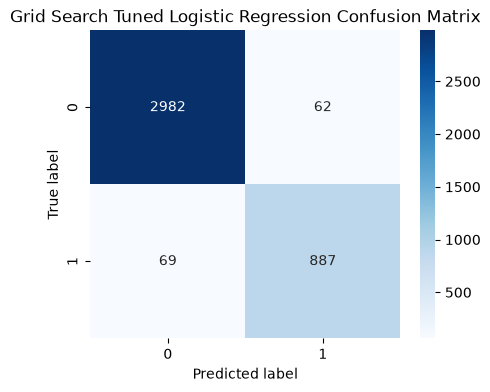

In [323]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr_grid)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Grid Search Tuned Logistic Regression Confusion Matrix")
plt.show()

In [324]:
print(classification_report(y_test, y_pred_lr_grid))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3044
           1       0.93      0.93      0.93       956

    accuracy                           0.97      4000
   macro avg       0.96      0.95      0.95      4000
weighted avg       0.97      0.97      0.97      4000



Compared to the untuned Logistic Regression model, the Grid Search tuned model maintained an overall 97% accuracy with only 62 false positives and 69 false negatives. The classification report also showed strong performance across both classes, indicating that Grid Search preserved the model’s excellent predictive ability but did not provide a significant improvement over the baseline model.

In [325]:
# Cross-validation
cv_scores_lr_grid = cross_val_score(
    logreg_grid_tuned_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:", cv_scores_lr_grid)
print(f"Mean CV Accuracy: {cv_scores_lr_grid.mean():.3f}")
print(f"Standard Deviation: {cv_scores_lr_grid.std():.3f}")

Cross-validation scores: [0.9621875 0.96125   0.9665625 0.96375   0.97     ]
Mean CV Accuracy: 0.965
Standard Deviation: 0.003


The Grid Search tuned Logistic Regression achieved a mean cross-validation accuracy of 96.5% with a very low standard deviation (0.003), indicating that the model performs consistently across different folds and generalizes well to unseen data.

##### Random Search CV for Logistic Regression


In [326]:
# Parameter distributions
param_dist_lr = {
    "classifier__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "classifier__penalty": ["l2"],
    "classifier__solver": ["lbfgs", "liblinear"]
}

In [327]:
# Random Search CV for logistic regression
random_search_lr = RandomizedSearchCV(
    estimator=logreg_pipeline,
    param_distributions=param_dist_lr,
    n_iter=10,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

# Fit the model
random_search_lr.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__C': [0.001, 0.01, ...], 'classifier__penalty': ['l2'], 'classifier__solver': ['lbfgs', 'liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metri

In [328]:
#Get best parameters
random_search_lr.best_params_

{'classifier__solver': 'liblinear',
 'classifier__penalty': 'l2',
 'classifier__C': 1}

In [329]:
# get best estimator
random_search_lr.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['Age','AnnualIncome','CreditScore',...,'InterestRate', 'MonthlyLoanPayment','TotalDebtToIncomeRatio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyi

In [330]:
# Tuned Logistic Regression Pipeline
logreg_random_tuned_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        C=1,
        penalty="l2",
        solver="liblinear",
        max_iter=1000,
        random_state=42
    ))
])

# Train the tuned model
logreg_random_tuned_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['Age','AnnualIncome','CreditScore',...,'InterestRate', 'MonthlyLoanPayment','TotalDebtToIncomeRatio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyi

In [331]:
# Get predictions
y_pred_lr_random = logreg_random_tuned_pipeline.predict(X_test)
y_proba_lr_random = logreg_random_tuned_pipeline.predict_proba(X_test)[:, 1]

In [332]:
# Evaluate Random Search Tuned Logistic Regression
accuracy = accuracy_score(y_test, y_pred_lr_random)
precision = precision_score(y_test, y_pred_lr_random)
recall = recall_score(y_test, y_pred_lr_random)
f1 = f1_score(y_test, y_pred_lr_random)
roc_auc = roc_auc_score(y_test, y_proba_lr_random)

# Display metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"ROC AUC Score: {roc_auc:.2f}")

Accuracy: 0.97
Precision: 0.93
Recall: 0.93
F1 Score: 0.93
ROC AUC Score: 0.99


Compared to the untuned Logistic Regression model, the Random Search tuned model maintained an excellent overall accuracy of 97%, with precision, recall, and F1-score all at 93%, while achieving an outstanding ROC-AUC score of 99%. This indicates that hyperparameter tuning preserved the already strong performance of Logistic Regression and resulted in a robust model with excellent discrimination between low-risk and high-risk loan applicants.

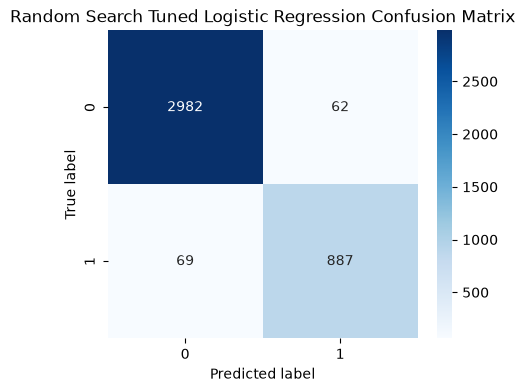

In [316]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr_random)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Random Search Tuned Logistic Regression Confusion Matrix")
plt.show()

In [318]:
#classification matrix
print(classification_report(y_test, y_pred_lr_random))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3044
           1       0.93      0.93      0.93       956

    accuracy                           0.97      4000
   macro avg       0.96      0.95      0.95      4000
weighted avg       0.97      0.97      0.97      4000



The Random Search tuned Logistic Regression correctly classified 2,982 non-default loans and 887 default loans, with only 62 false positives and 69 false negatives. The classification report shows an overall accuracy of 97%, with 93% precision, recall, and F1-score for the positive class. Compared to the untuned Logistic Regression model, Random Search did not produce a noticeable improvement, indicating that the default hyperparameters were already near optimal for this dataset.

In [333]:
# Cross-validation on Random Search Logistic Regression
cv_scores_lr_random = cross_val_score(
    logreg_random_tuned_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:", cv_scores_lr_random)
print(f"Mean CV Accuracy: {cv_scores_lr_random.mean():.3f}")
print(f"Standard Deviation: {cv_scores_lr_random.std():.3f}")

Cross-validation scores: [0.9621875 0.9621875 0.96625   0.9640625 0.9703125]
Mean CV Accuracy: 0.965
Standard Deviation: 0.003


The Random Search tuned Logistic Regression achieved a mean cross-validation accuracy of 96.5% with a very low standard deviation (0.003), indicating stable and consistent performance across the five folds. Compared to the untuned and Grid Search Logistic Regression models, Random Search did not provide any noticeable improvement, suggesting that the original hyperparameters were already near optimal for this dataset.

##### Grid Search CV for Random Forest

In [284]:
# Parameter grid for Random Forest

param_rf = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

In [285]:
#Grid Search CV
grid_search_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_rf,
    cv=5,
    scoring="accuracy",
    n_jobs=-1)

grid_search_rf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [None, 10, ...], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...], 'classifier__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... ver

In [286]:
# Best Estimator
grid_search_rf.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['Age','AnnualIncome','CreditScore',...,'InterestRate', 'MonthlyLoanPayment','TotalDebtToIncomeRatio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyi

In [287]:
# Best Parameters
grid_search_rf.best_params_

{'classifier__max_depth': 20,
 'classifier__min_samples_leaf': 2,
 'classifier__min_samples_split': 5,
 'classifier__n_estimators': 300}

In [288]:
# Check training and testing accuracy for tuned Random Forest
rf_grid_train_score = grid_search_rf.score(X_train, y_train)
rf_grid_test_score = grid_search_rf.score(X_test, y_test)

print(f"Training Accuracy: {rf_grid_train_score:.3f}")
print(f"Testing Accuracy: {rf_grid_test_score:.3f}")

Training Accuracy: 0.998
Testing Accuracy: 0.930


In [289]:
#create the tuned random forest using the best params
rf_tuned_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ))
])

In [290]:
#train the model
rf_tuned_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['Age','AnnualIncome','CreditScore',...,'InterestRate', 'MonthlyLoanPayment','TotalDebtToIncomeRatio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyi

In [291]:
#get the predictions
y_pred_rf_tuned = rf_tuned_pipeline.predict(X_test)
y_proba_rf_tuned = rf_tuned_pipeline.predict_proba(X_test)[:, 1]

In [292]:
# Evaluate Tuned Random Forest metrics

accuracy = accuracy_score(y_test, y_pred_rf_tuned)
precision = precision_score(y_test, y_pred_rf_tuned)
recall = recall_score(y_test, y_pred_rf_tuned)
f1 = f1_score(y_test, y_pred_rf_tuned)
roc_auc = roc_auc_score(y_test, y_proba_rf_tuned)

# Display evaluation metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"ROC AUC Score: {roc_auc:.2f}")

Accuracy: 0.93
Precision: 0.89
Recall: 0.81
F1 Score: 0.85
ROC AUC Score: 0.98


The tuned Random Forest model achieved similar performance to the baseline model. Accuracy (0.93), F1-score (0.85), and ROC-AUC (0.98) remained unchanged, while recall improved slightly from 0.80 to 0.81 with a small decrease in precision. This indicates that Grid Search produced only a marginal improvement, suggesting the baseline model was already well optimized.

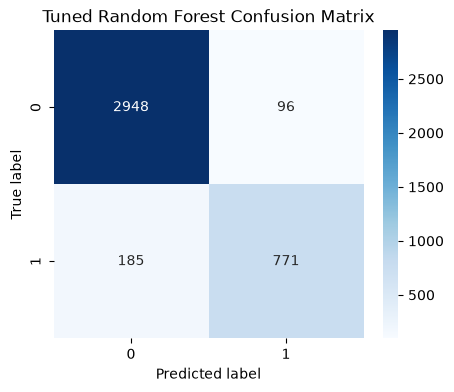

In [293]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_rf_tuned)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["0","1"],
    yticklabels=["0","1"]
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Tuned Random Forest Confusion Matrix")
plt.show()

The tuned Random Forest model correctly classified 2,948 non-default loans (True Negatives) and 771 default loans (True Positives). It produced 96 False Positives and 185 False Negatives, indicating a slight improvement in detecting default loans while maintaining a relatively low number of incorrect predictions.

In [294]:
# Classification Report

print(classification_report(y_test, y_pred_rf_tuned))

              precision    recall  f1-score   support

           0       0.94      0.97      0.95      3044
           1       0.89      0.81      0.85       956

    accuracy                           0.93      4000
   macro avg       0.92      0.89      0.90      4000
weighted avg       0.93      0.93      0.93      4000



The tuned Random Forest achieved an overall accuracy of 93%. It obtained a precision of 0.89, recall of 0.81, and an F1-score of 0.85 for the positive class. Compared to the untuned model, recall improved slightly, showing that the tuned model identified more default loan applicants while maintaining similar overall performance.

In [295]:
# Cross Validation

cv_scores_rf_tuned = cross_val_score(
    rf_tuned_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:", cv_scores_rf_tuned)
print(f"Mean CV Accuracy: {cv_scores_rf_tuned.mean():.3f}")
print(f"Standard Deviation: {cv_scores_rf_tuned.std():.3f}")

Cross-validation scores: [0.9284375 0.9228125 0.9296875 0.9259375 0.934375 ]
Mean CV Accuracy: 0.928
Standard Deviation: 0.004


The tuned Random Forest achieved a mean cross-validation accuracy of 0.928 with a standard deviation of 0.004. The low standard deviation indicates that the model performed consistently across the five folds, suggesting good stability and reliable generalization to unseen data.

* Cross-validation accuracy improved slightly (92.6% → 92.8%).
* Grid Search gave a small but measurable improvement, even though the test metrics changed very little.

##### Random Search CV for Random Forest

In [296]:
#Randomised Search CV for Random Forest
param_dist_rf = {
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__max_depth": [10, 20, 30, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

In [297]:
#create the cv and fit 
random_search_rf = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist_rf,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_search_rf.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__max_depth': [10, 20, ...], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...], 'classifier__n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly 

In [298]:
#Get the best Parameters
random_search_rf.best_params_

{'classifier__n_estimators': 200,
 'classifier__min_samples_split': 2,
 'classifier__min_samples_leaf': 1,
 'classifier__max_depth': 30}

In [299]:
# get Best Estimator
random_search_rf.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['Age','AnnualIncome','CreditScore',...,'InterestRate', 'MonthlyLoanPayment','TotalDebtToIncomeRatio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyi

In [300]:
#recreate model using best params and fit the model
rf_random_tuned_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=30,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42
    ))
])

rf_random_tuned_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['Age','AnnualIncome','CreditScore',...,'InterestRate', 'MonthlyLoanPayment','TotalDebtToIncomeRatio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyi

In [301]:
# Get predictions
y_pred_rf_random = rf_random_tuned_pipeline.predict(X_test)
y_proba_rf_random = rf_random_tuned_pipeline.predict_proba(X_test)[:, 1]

In [303]:
# Evaluate Random Search Tuned Random Forest
accuracy = accuracy_score(y_test, y_pred_rf_random)
precision = precision_score(y_test, y_pred_rf_random)
recall = recall_score(y_test, y_pred_rf_random)
f1 = f1_score(y_test, y_pred_rf_random)
roc_auc = roc_auc_score(y_test, y_proba_rf_random)

# Display metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"ROC AUC Score: {roc_auc:.2f}")

Accuracy: 0.93
Precision: 0.90
Recall: 0.81
F1 Score: 0.85
ROC AUC Score: 0.98


Observation: The Random Search tuned Random Forest achieved an accuracy of 93%, with a precision of 90%, recall of 81%, F1-score of 85%, and ROC-AUC of 98%. These results are almost identical to the untuned Random Forest model, indicating that Random Search did not significantly improve predictive performance despite selecting a different combination of hyperparameters.

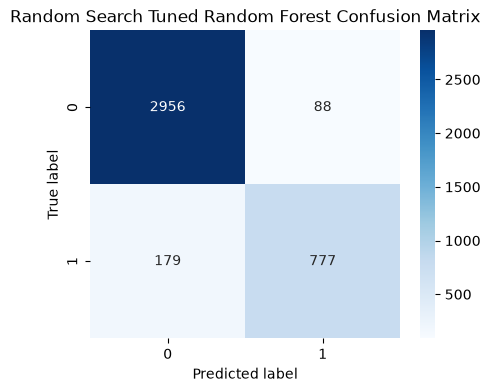

In [304]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf_random)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["0","1"],
    yticklabels=["0","1"]
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Random Search Tuned Random Forest Confusion Matrix")
plt.show()

Observation: The Random Search tuned Random Forest correctly classified 2,956 non-default loan applications (True Negatives) and 777 default loan applications (True Positives). It misclassified 88 non-default applicants as defaults (False Positives) and 179 default applicants as non-defaults (False Negatives). Compared to the Grid Search tuned model, Random Search reduced the number of false negatives, meaning it identified slightly more risky loan applicants correctly.

In [305]:
#Classification Report
print(classification_report(y_test, y_pred_rf_random))

              precision    recall  f1-score   support

           0       0.94      0.97      0.96      3044
           1       0.90      0.81      0.85       956

    accuracy                           0.93      4000
   macro avg       0.92      0.89      0.91      4000
weighted avg       0.93      0.93      0.93      4000



Observation: The Random Search tuned Random Forest achieved an overall accuracy of 93%. The model attained a precision of 90%, recall of 81%, and F1-score of 85% for the positive class. Compared to the Grid Search tuned model, the recall improved slightly while maintaining similar precision and overall accuracy, indicating a small improvement in detecting risky loan applicants.

In [302]:
#cross validation on random search
cv_scores_rf_random = cross_val_score(
    rf_random_tuned_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:", cv_scores_rf_random)
print(f"Mean CV Accuracy: {cv_scores_rf_random.mean():.3f}")
print(f"Standard Deviation: {cv_scores_rf_random.std():.3f}")

Cross-validation scores: [0.926875  0.924375  0.928125  0.925     0.9334375]
Mean CV Accuracy: 0.928
Standard Deviation: 0.003


Observation: The Random Search tuned Random Forest achieved a mean cross-validation accuracy of 92.8% with a standard deviation of 0.003. The low standard deviation indicates that the model performs consistently across different folds and generalizes well to unseen data. Its cross-validation performance is nearly identical to the Grid Search tuned model, suggesting that both tuning methods produced stable and reliable models.

In [334]:
# Final model comparison table

final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression - Grid Search",
        "Logistic Regression - Random Search",
        "Decision Tree",
        "Random Forest",
        "Random Forest - Grid Search",
        "Random Forest - Random Search"
    ],
    
    "Accuracy": [0.97, 0.97, 0.97, 0.88, 0.93, 0.93, 0.93],
    "Precision": [0.93, 0.93, 0.93, 0.75, 0.90, 0.89, 0.90],
    "Recall": [0.93, 0.93, 0.93, 0.77, 0.80, 0.81, 0.81],
    "F1 Score": [0.93, 0.93, 0.93, 0.76, 0.85, 0.85, 0.85],
    "ROC AUC": [0.99, 0.99, 0.99, 0.84, 0.98, 0.98, 0.98],
    "Mean CV Accuracy": [0.965, 0.965, 0.965, 0.887, 0.926, 0.928, 0.928]
})

final_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Mean CV Accuracy
0,Logistic Regression,0.97,0.93,0.93,0.93,0.99,0.965
1,Logistic Regression - Grid Search,0.97,0.93,0.93,0.93,0.99,0.965
2,Logistic Regression - Random Search,0.97,0.93,0.93,0.93,0.99,0.965
3,Decision Tree,0.88,0.75,0.77,0.76,0.84,0.887
4,Random Forest,0.93,0.90,0.80,0.85,0.98,0.926
5,Random Forest - Grid Search,0.93,0.89,0.81,0.85,0.98,0.928
6,Random Forest - Random Search,0.93,0.90,0.81,0.85,0.98,0.928


In [335]:
# Sort models by overall performance
final_comparison.sort_values(
    by=["Accuracy", "F1 Score", "ROC AUC", "Mean CV Accuracy"],
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Mean CV Accuracy
0,Logistic Regression,0.97,0.93,0.93,0.93,0.99,0.965
1,Logistic Regression - Grid Search,0.97,0.93,0.93,0.93,0.99,0.965
2,Logistic Regression - Random Search,0.97,0.93,0.93,0.93,0.99,0.965
5,Random Forest - Grid Search,0.93,0.89,0.81,0.85,0.98,0.928
6,Random Forest - Random Search,0.93,0.90,0.81,0.85,0.98,0.928
4,Random Forest,0.93,0.90,0.80,0.85,0.98,0.926
3,Decision Tree,0.88,0.75,0.77,0.76,0.84,0.887


Based on the evaluation metrics, Logistic Regression was selected as the final model for predicting loan default risk. It consistently outperformed Decision Tree and Random Forest in terms of accuracy, F1-score, ROC-AUC, and cross-validation performance. Although both Grid Search and Random Search were applied, they did not improve upon the untuned Logistic Regression model, suggesting that its default hyperparameters were already well suited to the dataset. Therefore, the untuned Logistic Regression model was chosen as the final model because it provides excellent predictive performance while remaining simpler and more computationally efficient than the tuned alternatives.

## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements